In [102]:
import matplotlib.pyplot as plt
from loadPressureData import loadPressureData
from pathlib import Path
import numpy as np
from BulkWaveStats import detide, Spp_to_Seta, sig_wave_height
from scipy.signal import spectrogram


This notebook follows the computations performed on Becker(2014) *Water Level Effects on breaking wave setup for Pacific Island fringing reefs*

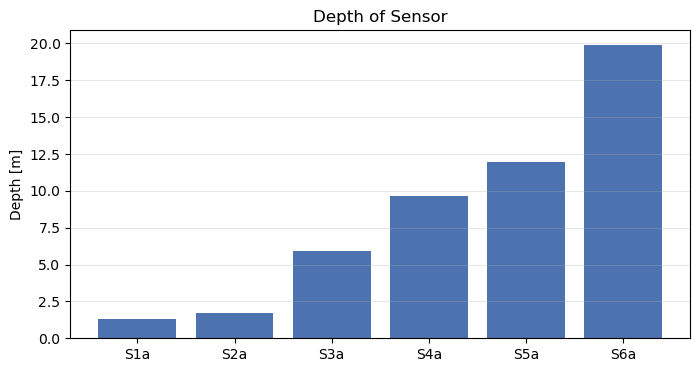

In [3]:
# need to decide where the reef flat/reef face is 
labels = ['S1a', 'S2a', 'S3a', 'S4a', 'S5a', 'S6a']
depths = [1.3, 1.74, 5.90, 9.64, 11.95, 19.9]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(labels, depths, color="#4C72B0")
ax.set_ylabel("Depth [m]")
ax.set_title("Depth of Sensor")
ax.grid(axis="y", alpha=0.3)
plt.show()

since sensor 1 and 2 are ~same depth, i'm going to assumer that sensor 3 is the end of the reef face. but will talk to mark about that. 

**From Paper**

- Sea surface elevation time series for wind waves are obtained indirectly using linear theory to depth correct the detided 15 min subrecords of bottom pressure, or directly in the case of the offshore AWAC sensors using acoustic surface tracking. 

- The rms wave height, H, is computed  over 15 min records as $2\sqrt{2\sigma}$, where $\sigma$ is the standard deviation from the surface elevation spectrum integrated between 0.033 and 0.35 Hz for Roi and CMI, and 0.04 and 0.30 Hz for Ipan. At the deep offshore sensors at CMI and Roi (13.8 m), we compute H using the acoustically tracked sea surface elevation measurements.

#### Load, average, and detide data

In [ ]:
## ----- Sensor 1 ----- ##
bursts1 = loadPressureData(Path("data/MoA18411.mat"))
t1 = bursts1.time           # numpy datetime64[ns]
h1 = bursts1.depth_m       # hydrostatic depth in meters
p1 = bursts1.pressure_pa

# detide
tide1, p1_detide, p1_raw = detide(p1, t1, LAT = 21.58055556)


prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.


#### Compute elevation spectra

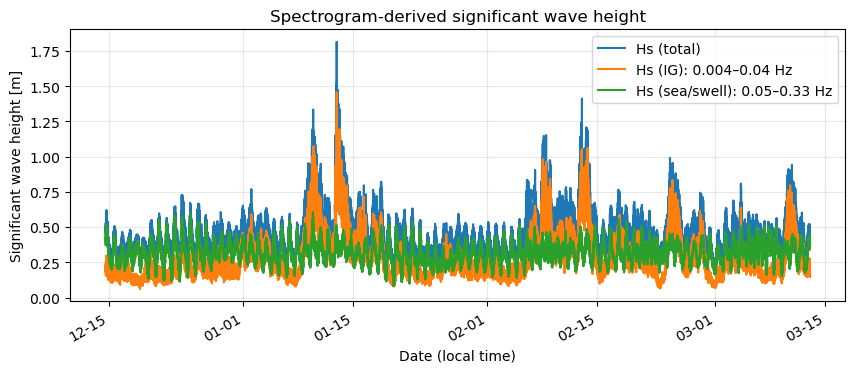

In [104]:
# INPUT VALUES
fs = 1
nperseg = 900 #15 min windows
noverlap = nperseg * 0.75 # 75% overlap

# compute pressure spectra
freqs, t_spec, Spp1 = spectrogram(
    p1_detide,
    fs=fs,
    window = 'hann',
    nperseg = nperseg,
    noverlap = noverlap, 
    detrend = 'linear',
    scaling = 'density',
    mode='psd', 
)

# convert to surface elevation
Seta1, t_eta1, h_eta1 = Spp_to_Seta(Spp1, freqs, t_spec, t1, h1)
autospec = np.nanmean(Seta1, axis=1)  # average across time windows

# compute rms wave height using sig wave height. H
# Hs = 4*sigma so Hrms = sqrt(2)/2 * Hs
Hs_tot, Hs_ig, Hs_ss, Tp_ss, t_center = sig_wave_height(Seta1, freqs, t_spec, t1, h1)
Hrms = np.sqrt(2)/2 * Hs_ss


Text(0.5, 1.0, 'Autospectra of detided Sensor 1 with nperseg=900')

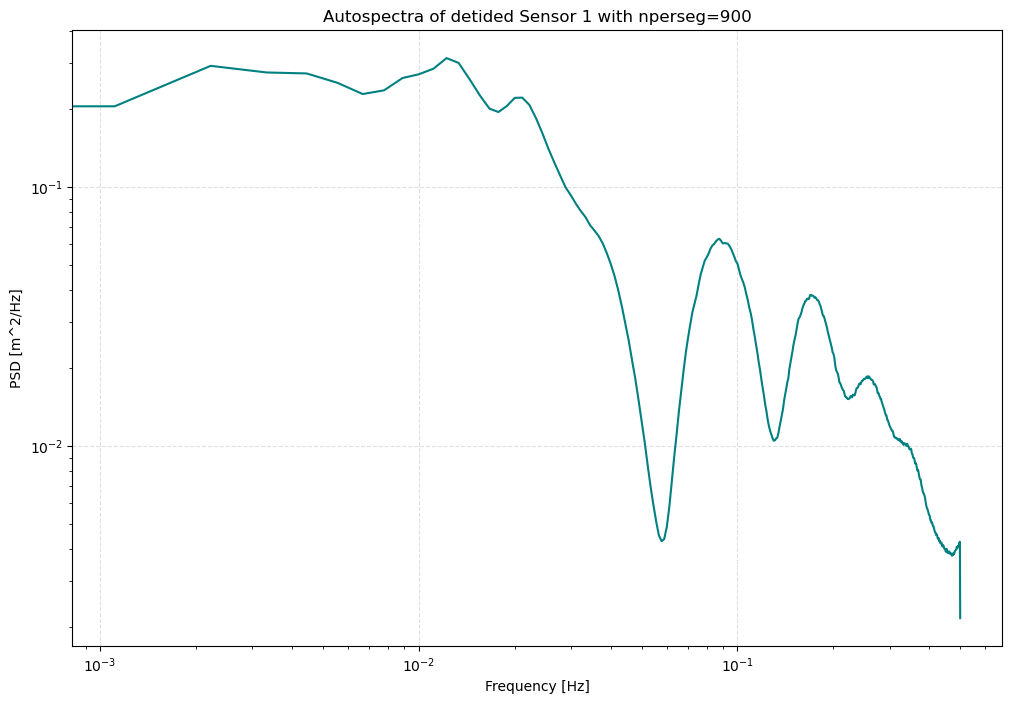

In [112]:

plt.figure(figsize=(12, 8))
plt.loglog(freqs, autospec, color='teal')
plt.grid(True, linestyle='--', alpha=0.4)
plt.xlabel('Frequency [Hz]')
plt.ylabel('PSD [m^2/Hz]')
plt.title('Autospectra of detided Sensor 1 with nperseg={}'.format(nperseg))

Text(0, 0.5, 'height (m)')

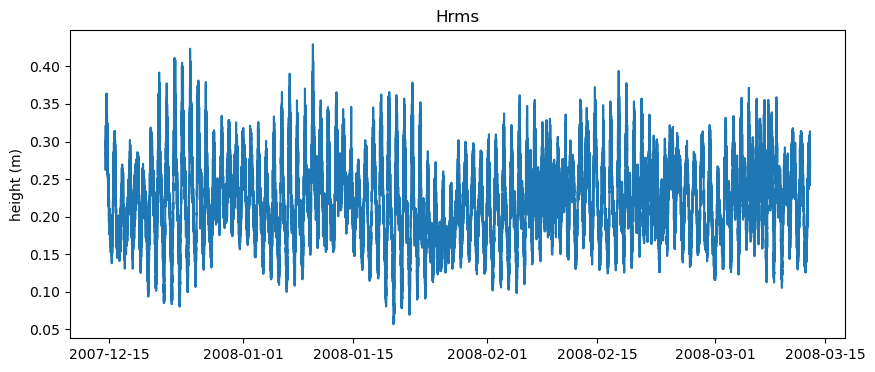

In [110]:
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(t_center, Hrms)
ax.set_title('Hrms')
ax.set_ylabel('height (m)')

#### Compute RMS Wave Height, H

In [85]:
band = (freqs >= 0.033) & (freqs <= 0.35)
m0 = np.trapz(Seta1[band, :], freqs[band], axis=0)          # variance per window
Hrms = 2 * np.sqrt(2 * np.maximum(m0, 0.0) )#np.max to ensure no negative values

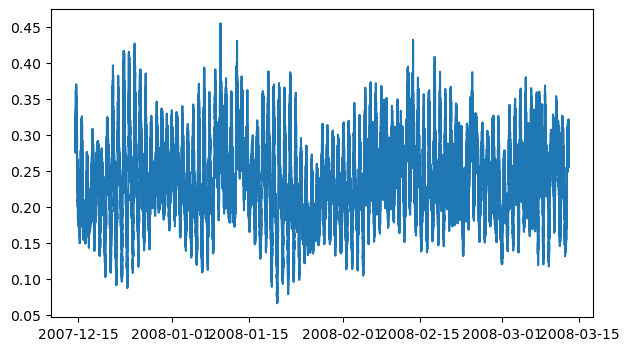

In [91]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(t_eta1, Hrms)

In [96]:
eta_idx = pd.to_datetime(t1)  # 1 Hz index
eta_band_std = (
    pd.Series(eta_band, index=eta_idx)
    .rolling(window=nperseg, center=True, min_periods=nperseg//2)
    .std()
)

t_eta_idx = pd.to_datetime(t_eta1).round("S")  # align with 1 s grid
Hrms_time = 2.0 * np.sqrt(2.0) * (
    eta_band_std.reindex(t_eta_idx, method="nearest", tolerance="1s")
).to_numpy()


/var/folders/7q/04p1sn755vg5x39skt2hykjh0000gn/T/ipykernel_93208/2526224342.py:8: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  t_eta_idx = pd.to_datetime(t_eta1).round("S")  # align with 1 s grid
